# YOLOv8s Single Model Training + Evaluation
## Run cells top to bottom in order
> **Dataset:** Your dataset stays on Google Drive — it is downloaded into this session via `gdown`.
> No need to upload anything to Kaggle.
> ```
> Google Drive (your side):
>   yolo_dataset/
>     data.yaml
>     train/images/  train/labels/
>     val/images/    val/labels/
>     test/images/   test/labels/
> ```
> **Lines marked** ✏️ **are the only ones you may need to edit.**

## 1. Download Dataset from Google Drive (no upload needed)
> ✏️ Replace `DRIVE_FOLDER_ID` with the folder ID of your dataset on Google Drive.
> To get it: right-click your dataset folder in Drive → **Share** → copy the ID from the URL
> (the part after `/folders/`).
>
> **Tip:** For very large datasets, zip the folder first and share the zip file instead,
> then use `gdown.download(file_id, ...)` + `!unzip` — it will be much faster.

In [1]:
import os

# ✏️ Paste the file ID of your dataset.zip here
DRIVE_ZIP_FILE_ID = '1dK16BAmZXpXCvazsWgI73OQ7_ts8-PfX'

!pip install -q gdown
import gdown

os.makedirs('/kaggle/working/dataset', exist_ok=True)

# Download the zip
gdown.download(
    f'https://drive.google.com/uc?id={DRIVE_ZIP_FILE_ID}',
    '/kaggle/working/dataset.zip',
    quiet=False,
    fuzzy=True
)

# Unzip it
!unzip -q /kaggle/working/dataset.zip -d /kaggle/working/dataset

print('✅ Dataset downloaded and extracted')
print(os.listdir('/kaggle/working/dataset'))

Downloading...
From (original): https://drive.google.com/uc?id=1dK16BAmZXpXCvazsWgI73OQ7_ts8-PfX
From (redirected): https://drive.google.com/uc?id=1dK16BAmZXpXCvazsWgI73OQ7_ts8-PfX&confirm=t&uuid=5f70e1de-9d9b-4e79-9afb-7fd5680e1e4f
To: /kaggle/working/dataset.zip
100%|██████████| 3.15G/3.15G [00:20<00:00, 152MB/s] 


✅ Dataset downloaded and extracted
['dataset']


In [3]:
import os
# Verify the dataset structure
print(os.listdir('/kaggle/working/dataset'))

['dataset']


## 2. Load Dataset
> ✏️ Edit `DATASET_SUBFOLDER` if your dataset is nested inside an extra folder

In [4]:
import os, yaml

# Auto-detect where data.yaml is after extraction
def find_dataset_root(base_dir):
    for root, dirs, files in os.walk(base_dir):
        if 'data.yaml' in files:
            return root
    return None

DATASET_PATH = find_dataset_root('/kaggle/working/dataset')

if DATASET_PATH is None:
    raise FileNotFoundError(
        "data.yaml not found anywhere under /kaggle/working/dataset/\n"
        "Check the zip structure with: !unzip -l /kaggle/working/dataset.zip | head -20"
    )

print('=' * 55)
print('LOADING DATASET')
print('=' * 55)
print(f'✅ Dataset root auto-detected at:\n   {DATASET_PATH}')

# Fix data.yaml paths to point to the Kaggle working directory
data_yaml_path = f'{DATASET_PATH}/data.yaml'
with open(data_yaml_path) as f:
    data_config = yaml.safe_load(f)
data_config['train'] = f'{DATASET_PATH}/train/images'
data_config['val']   = f'{DATASET_PATH}/val/images'
data_config['test']  = f'{DATASET_PATH}/test/images'
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print('\n✅ Dataset ready!')
for split in ['train', 'val', 'test']:
    img_dir = f'{DATASET_PATH}/{split}/images'
    lbl_dir = f'{DATASET_PATH}/{split}/labels'
    n_imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    n_lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    status = '✅' if n_imgs > 0 else '⚠️'
    print(f'  {status} {split:6s}: {n_imgs} images, {n_lbls} labels')
print(f'\nClasses: {data_config.get("names", "?")}')

LOADING DATASET
✅ Dataset root auto-detected at:
   /kaggle/working/dataset/dataset

✅ Dataset ready!
  ✅ train : 24583 images, 24583 labels
  ✅ val   : 1526 images, 1526 labels
  ✅ test  : 740 images, 740 labels

Classes: ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']


## 3. Install Dependencies

In [5]:
!pip install -q ultralytics supervision opencv-python seaborn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 18.9 MB/s eta 0:00:00


## 4. Imports

In [6]:
from ultralytics import YOLO
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2, os, shutil, yaml
from matplotlib.patches import Rectangle
print('✅ All imports done')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All imports done


## 5. Check GPU

In [7]:
!nvidia-smi
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Sat Apr 25 13:57:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 6. Global Configuration
> ✏️ Adjust `EPOCHS` and `BATCH` based on your GPU memory
> ✏️ Update `CLASS_NAMES` if your dataset has different classes

In [8]:
# ✏️ Training parameters
EPOCHS         = 50
BATCH          = 16
IMG_SIZE       = 640
CONF_THRESHOLD = 0.25
IOU_THRESHOLD  = 0.5

# ✏️ Update if your classes are different
CLASS_NAMES = [
    'Customer-Bagpack', 'Product', 'Product-Picked',
    'Shopping-Cart', 'Normal', 'Theft'
]

# -- Do not edit below this line --
DATA_YAML        = f'{DATASET_PATH}/data.yaml'
TEST_IMAGES_DIR  = f'{DATASET_PATH}/test/images'
TEST_LABELS_DIR  = f'{DATASET_PATH}/test/labels'
VALID_IMAGES_DIR = f'{DATASET_PATH}/val/images'
VALID_LABELS_DIR = f'{DATASET_PATH}/val/labels'

PROJECT_DIR   = '/kaggle/working/yolo_small'
MODEL_NAME    = 'yolov8s'
MODEL_WEIGHTS = 'yolov8s.pt'

NUM_WORKERS = 4

print('Configuration loaded:')
print(f'  EPOCHS={EPOCHS}  BATCH={BATCH}  IMG_SIZE={IMG_SIZE}')
print(f'  CONF={CONF_THRESHOLD}  IOU={IOU_THRESHOLD}')
print(f'  Model: {MODEL_NAME}')
print(f'  Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}')
print(f'  Dataset: {DATASET_PATH}')
print(f'  Output dir: {PROJECT_DIR}')

Configuration loaded:
  EPOCHS=50  BATCH=16  IMG_SIZE=640
  CONF=0.25  IOU=0.5
  Model: yolov8s
  Classes (6): ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'Normal', 'Theft']
  Dataset: /kaggle/working/dataset/dataset
  Output dir: /kaggle/working/yolo_small


## 7. Train YOLOv8s
> Trained weights are saved to `/kaggle/working/yolo_small/` and will appear
> in the **Output** tab of this notebook — you can download them from there.

In [9]:
os.chdir('/kaggle/working')
os.makedirs(PROJECT_DIR, exist_ok=True)

LOCAL_BEST = os.path.join(PROJECT_DIR, MODEL_NAME, "weights", "best.pt")

print('=' * 70)
print('TRAINING YOLOv8s')
print('=' * 70)

if os.path.exists(LOCAL_BEST):
    print('\n✅ YOLOv8s already trained — skipping')
else:
    if os.path.exists(MODEL_WEIGHTS) and os.path.getsize(MODEL_WEIGHTS) < 1_000_000:
        print(f'WARNING: Corrupt {MODEL_WEIGHTS} detected — deleting...')
        os.remove(MODEL_WEIGHTS)
    if not os.path.exists(MODEL_WEIGHTS):
        print(f'Downloading pretrained {MODEL_WEIGHTS}...')
        url = f'https://github.com/ultralytics/assets/releases/download/v8.2.0/{MODEL_WEIGHTS}'
        os.system(f'wget -q -O {MODEL_WEIGHTS} {url}')

    model = YOLO(MODEL_WEIGHTS)
    model.train(
        data=DATA_YAML, epochs=EPOCHS, imgsz=IMG_SIZE, batch=BATCH,
        device=0 if torch.cuda.is_available() else 'cpu',
        workers=NUM_WORKERS, project=PROJECT_DIR, name=MODEL_NAME,
        exist_ok=True, patience=15, amp=True, plots=True, save=True,
    )

if os.path.exists(LOCAL_BEST):
    print(f'\n💾 Saved to: {LOCAL_BEST}  (download from Kaggle Output tab)')
else:
    print('WARNING: best.pt not found — check training logs')

print('\n' + '=' * 70)
print('TRAINING COMPLETE — find weights in /kaggle/working/yolo_small/')
print('=' * 70)

TRAINING YOLOv8s
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

## 8. Evaluate YOLOv8s (mAP)

In [10]:
weights_path = os.path.join(PROJECT_DIR, MODEL_NAME, "weights", "best.pt")
if not os.path.exists(weights_path):
    raise FileNotFoundError(f'{MODEL_NAME} weights not found — run training first')

print('=' * 70)
print('EVALUATING YOLOv8s')
print('=' * 70)

val = YOLO(weights_path).val(data=DATA_YAML, split="val", verbose=True, plots=True)

print('\n' + '=' * 70)
print('RESULTS')
print('=' * 70)
print(f'  mAP50    : {val.box.map50:.4f}')
print(f'  mAP50-95 : {val.box.map:.4f}')
print(f'  Precision: {val.box.mp:.4f}')
print(f'  Recall   : {val.box.mr:.4f}')

EVALUATING YOLOv8s
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2469.3±820.8 MB/s, size: 132.7 KB)
val: Scanning /kaggle/working/dataset/dataset/val/labels.cache... 1526 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1526/1526 492.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 96/96 4.5it/s 21.3s0.2ss
                   all       1526       1751      0.958      0.864      0.908      0.784
                normal        585        742       0.96      0.931      0.976       0.88
                 theft        954       1009      0.955      0.797      0.841      0.688
Speed: 0.9ms preprocess, 9.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

RESULTS
  mAP50    : 0.9083
  mAP50-95 : 0.7841
  

## 9. Run Predictions on Test Set

In [11]:
weights_path = os.path.join(PROJECT_DIR, MODEL_NAME, "weights", "best.pt")
if not os.path.exists(weights_path):
    raise FileNotFoundError(f'{MODEL_NAME} weights not found — run training first')

print(f'✅ {MODEL_NAME}: {weights_path}')
print(f'\nRunning inference on: {TEST_IMAGES_DIR}')

model = YOLO(weights_path)
test_results = model.predict(
    source=TEST_IMAGES_DIR, conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD, save=False, verbose=False
)
total = sum(len(r.boxes) for r in test_results if r.boxes)
print(f'  {MODEL_NAME}: {total} total detections across {len(test_results)} images')
print('\n✅ Predictions done')

✅ yolov8s: /kaggle/working/yolo_small/yolov8s/weights/best.pt

Running inference on: /kaggle/working/dataset/dataset/test/images
  yolov8s: 783 total detections across 740 images

✅ Predictions done


## 10. Precision / Recall / F1 on Test Set

In [12]:
def calculate_iou(box1, box2):
    xa = max(box1[0], box2[0]); ya = max(box1[1], box2[1])
    xb = min(box1[2], box2[2]); yb = min(box1[3], box2[3])
    inter = max(0, xb-xa) * max(0, yb-ya)
    a1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    a2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    return inter / (a1 + a2 - inter + 1e-6)

def load_ground_truth(label_path, img_w, img_h):
    gt = []
    if not os.path.exists(label_path): return gt
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls, xc, yc, bw, bh = map(float, parts[:5])
            gt.append({'cls': int(cls), 'box': [
                int((xc-bw/2)*img_w), int((yc-bh/2)*img_h),
                int((xc+bw/2)*img_w), int((yc+bh/2)*img_h)]})
    return gt

total_TP = total_FP = total_FN = 0
class_m = {i: {'TP':0,'FP':0,'FN':0} for i in range(len(CLASS_NAMES))}

for res in test_results:
    img = cv2.imread(res.path)
    if img is None: continue
    h, w = img.shape[:2]
    lbl_file = os.path.join(
        TEST_LABELS_DIR,
        os.path.splitext(os.path.basename(res.path))[0] + '.txt'
    )
    gt_boxes    = load_ground_truth(lbl_file, w, h)
    pred_boxes  = res.boxes.xyxy.cpu().numpy()            if res.boxes else []
    pred_scores = res.boxes.conf.cpu().numpy()            if res.boxes else []
    pred_labels = res.boxes.cls.cpu().numpy().astype(int) if res.boxes else []

    matched_gt = set()
    for pb, ps, pl in zip(pred_boxes, pred_scores, pred_labels):
        cls = int(pl)
        matched = False
        for gi, gt in enumerate(gt_boxes):
            if gi in matched_gt: continue
            if cls == gt["cls"] and calculate_iou(pb, gt["box"]) >= IOU_THRESHOLD:
                total_TP += 1
                if cls < len(CLASS_NAMES): class_m[cls]['TP'] += 1
                matched_gt.add(gi); matched = True; break
        if not matched:
            total_FP += 1
            if cls < len(CLASS_NAMES): class_m[cls]['FP'] += 1
    for gi, gt in enumerate(gt_boxes):
        if gi not in matched_gt:
            total_FN += 1
            if gt['cls'] < len(CLASS_NAMES): class_m[gt['cls']]['FN'] += 1

precision = total_TP / (total_TP + total_FP + 1e-6)
recall    = total_TP / (total_TP + total_FN + 1e-6)
f1        = 2 * precision * recall / (precision + recall + 1e-6)

print('=' * 50)
print('TEST SET EVALUATION — YOLOv8s')
print('=' * 50)
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1        : {f1:.4f}')
print(f'  TP={total_TP}  FP={total_FP}  FN={total_FN}')

print('\nPer-Class breakdown:')
print(f'{"Class":<22} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 56)
for i, name in enumerate(CLASS_NAMES):
    m = class_m[i]
    p = m['TP']/(m['TP']+m['FP']+1e-6)
    r = m['TP']/(m['TP']+m['FN']+1e-6)
    f = 2*p*r/(p+r+1e-6)
    print(f'{name:<22} {p:>10.3f} {r:>10.3f} {f:>10.3f}')

TEST SET EVALUATION — YOLOv8s
  Precision : 0.7893
  Recall    : 0.5765
  F1        : 0.6663
  TP=618  FP=165  FN=454

Per-Class breakdown:
Class                   Precision     Recall         F1
--------------------------------------------------------
Customer-Bagpack            0.000      0.000      0.000
Product                     0.000      0.000      0.000
Product-Picked              0.000      0.000      0.000
Shopping-Cart               0.000      0.000      0.000
Normal                      0.792      0.388      0.521
Theft                       0.787      0.912      0.845


## 11. Visualize Detections on Test Images
> ✏️ Change `NUM_IMAGES_TO_SHOW` to control how many images are displayed

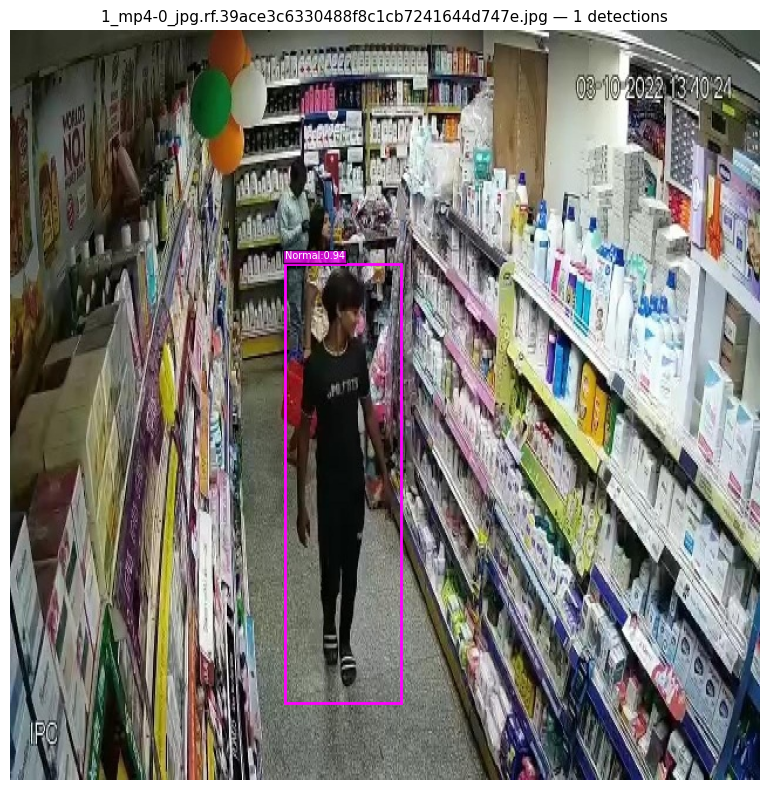

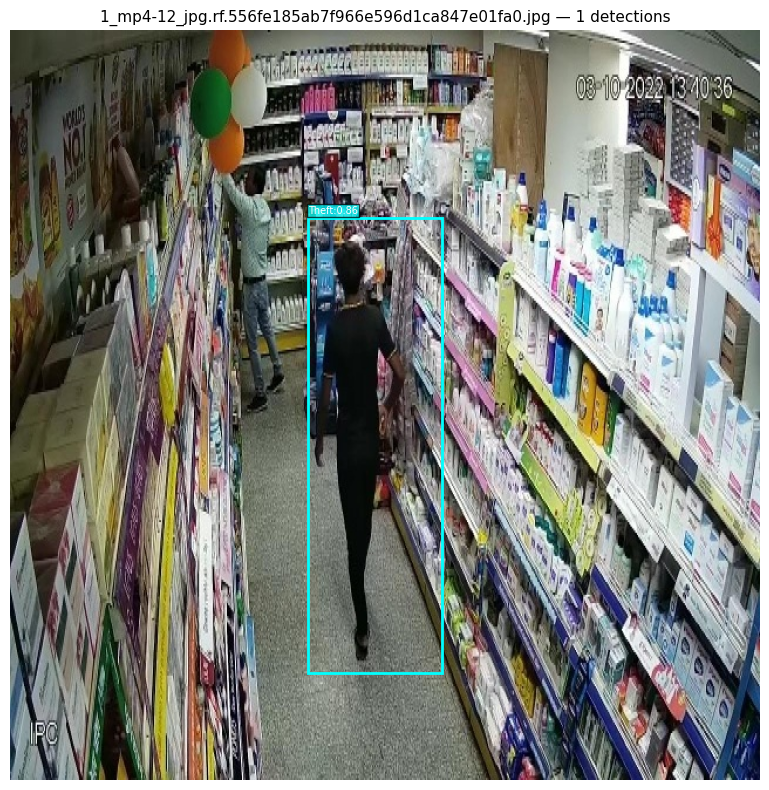

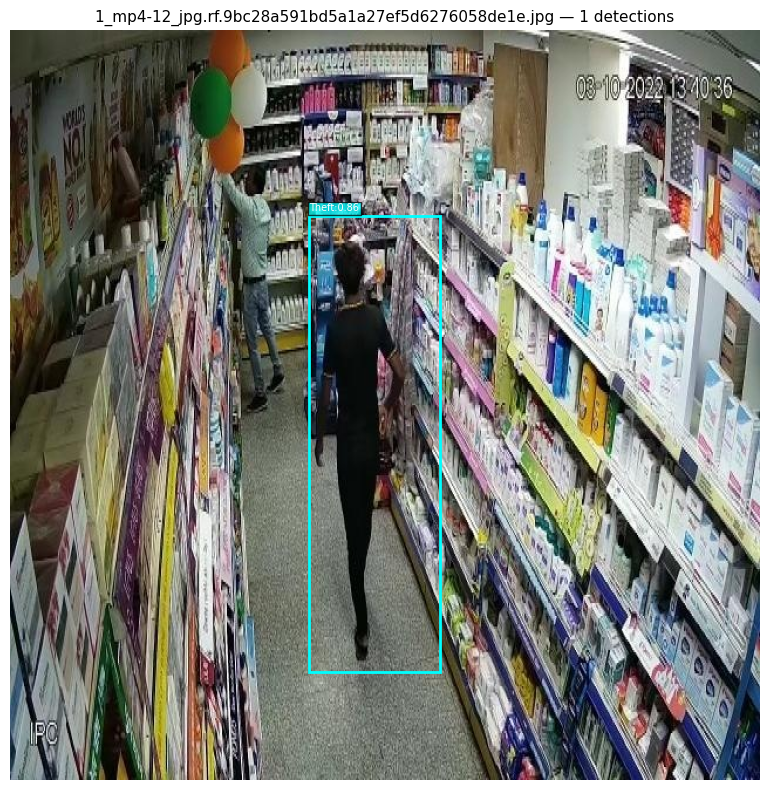

In [13]:
NUM_IMAGES_TO_SHOW = 3  # ✏️ Edit this number

COLORS = [
    (255,  0,  0),  # Customer-Bagpack
    (  0,255,  0),  # Product
    (  0,  0,255),  # Product-Picked
    (255,255,  0),  # Shopping-Cart
    (255,  0,255),  # Normal
    (  0,255,255),  # Theft
]

for res in test_results[:NUM_IMAGES_TO_SHOW]:
    img = cv2.imread(res.path)
    if img is None: continue
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(rgb)

    if res.boxes and len(res.boxes) > 0:
        boxes  = res.boxes.xyxy.cpu().numpy()
        scores = res.boxes.conf.cpu().numpy()
        labels = res.boxes.cls.cpu().numpy().astype(int)
        for box, lbl, scr in zip(boxes, labels, scores):
            x1,y1,x2,y2 = map(int, box)
            color = [c/255 for c in COLORS[lbl % len(COLORS)]]
            ax.add_patch(Rectangle((x1,y1),x2-x1,y2-y1,
                linewidth=2, edgecolor=color, fill=False))
            ax.text(x1,y1-4, f'{CLASS_NAMES[lbl]}:{scr:.2f}',
                fontsize=7, color='white',
                bbox=dict(fc=color, alpha=0.75, pad=1))

    n_det = len(res.boxes) if res.boxes else 0
    ax.set_title(f'{os.path.basename(res.path)} — {n_det} detections', fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 12. Test on a New Unseen Image
> ✏️ Change `TEST_IMAGE_PATH` to any image path on this Kaggle session.
> You can upload a single test image via **+ Add Data → Upload** or download it with `gdown`.

Downloading...
From: https://drive.google.com/uc?id=1ITucIh-Qc3OlH8W5Xmr4p9nTBSNXgWUp
To: /kaggle/working/test_image.jpg
100%|██████████| 394k/394k [00:00<00:00, 99.5MB/s]


Image loaded successfully: /kaggle/working/test_image.jpg
Detections: 2


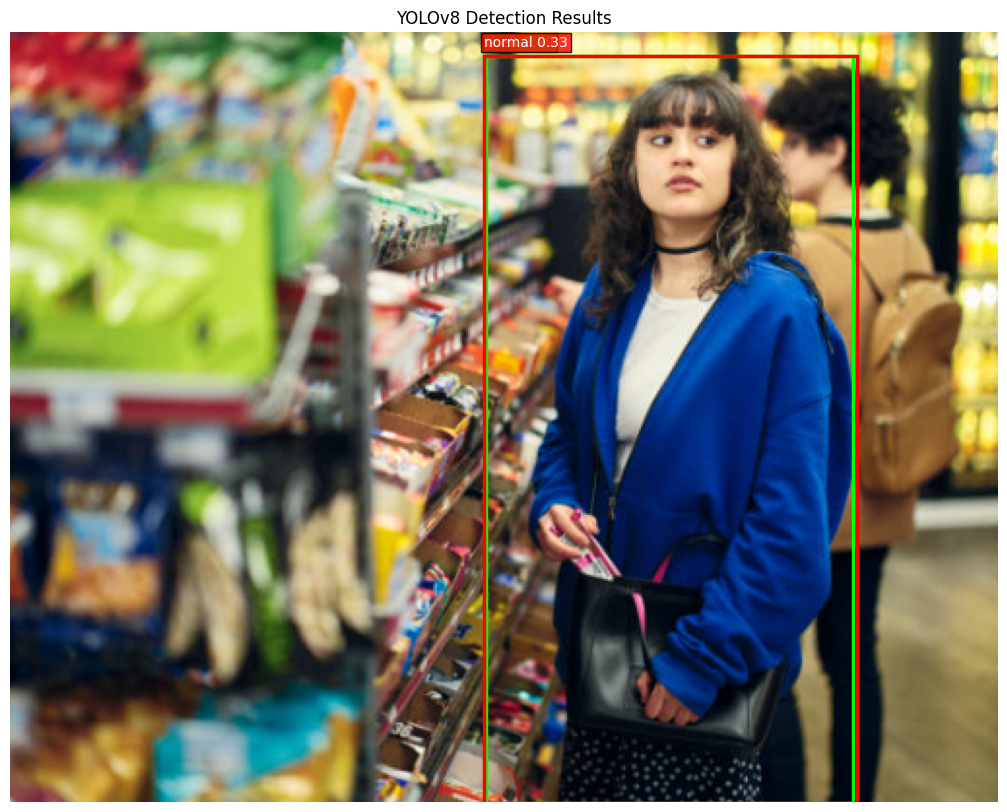

In [22]:
# =========================
# 1. Install gdown
# =========================
!pip install -q gdown

import os
import cv2
import gdown
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from ultralytics import YOLO

# =========================
# 2. Google Drive file ID
# =========================
FILE_ID = "1ITucIh-Qc3OlH8W5Xmr4p9nTBSNXgWUp"

TEST_IMAGE_PATH = "/kaggle/working/test_image.jpg"

# =========================
# 3. Download image
# =========================
url = f"https://drive.google.com/uc?id={FILE_ID}"

print("Downloading image from Google Drive...")

gdown.download(
    url,
    TEST_IMAGE_PATH,
    quiet=False,
    fuzzy=True
)

# =========================
# 4. Check image
# =========================
if not os.path.exists(TEST_IMAGE_PATH):
    raise FileNotFoundError("Download failed. Check Drive permissions.")

img = cv2.imread(TEST_IMAGE_PATH)

if img is None:
    raise FileNotFoundError("File exists but cannot be read as image.")

print("Image loaded successfully:", TEST_IMAGE_PATH)

# =========================
# 5. Load YOLO model
# =========================
weights_path = os.path.join(PROJECT_DIR, MODEL_NAME, "weights", "best.pt")
model = YOLO(weights_path)

CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.45

CLASS_NAMES = [
    "Customer-Bagpack",
    "Normal",
    "Product",
    "Product-Picked"
]

# =========================
# 6. Run inference
# =========================
result = model.predict(
    source=TEST_IMAGE_PATH,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    verbose=False
)[0]

print("Detections:", len(result.boxes) if result.boxes else 0)

# =========================
# 7. Visualize
# =========================
COLORS = [
    (255,0,0),
    (0,255,0),
    (0,0,255),
    (255,255,0)
]

fig, ax = plt.subplots(figsize=(14,10))
ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

if result.boxes is not None and len(result.boxes) > 0:

    boxes = result.boxes.xyxy.cpu().numpy()
    scores = result.boxes.conf.cpu().numpy()
    labels = result.boxes.cls.cpu().numpy().astype(int)
    
    for box, lbl, scr in zip(boxes, labels, scores):
    
        x1, y1, x2, y2 = map(int, box)
        color = [c/255 for c in COLORS[lbl % len(COLORS)]]
    
        ax.add_patch(Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor=color,
            linewidth=2.5
        ))
    
        label_name = model.names[int(lbl)]   # ✅ FIX HERE
    
        ax.text(
            x1,
            y1 - 5,
            f"{label_name} {scr:.2f}",
            color="white",
            bbox=dict(fc=color, alpha=0.8, pad=2)
        )

plt.title("YOLOv8 Detection Results")
plt.axis("off")
plt.show()

In [21]:
print(model.names)

{0: 'Customer-Bagpack', 1: 'Product', 2: 'Product-Picked', 3: 'Shopping-Cart', 4: 'normal', 5: 'theft'}


In [23]:
import shutil

shutil.make_archive(
    "/kaggle/working/results",
    'zip',
    "/kaggle/working"
)

print("ZIP created: /kaggle/working/results.zip")

ZIP created: /kaggle/working/results.zip


In [24]:
!pip install -q pydrive2

In [25]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()

gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()

drive = GoogleDrive(gauth)

print("Authenticated")

Authenticated


In [26]:
file_path = "/kaggle/working/results.zip"

file_name = "results.zip"

gfile = drive.CreateFile({'results': file_name})

gfile.SetContentFile(file_path)

print("Uploading... this may take time for 6.5GB")

gfile.Upload()

print("Upload completed ✔")

Uploading... this may take time for 6.5GB
Upload completed ✔


In [29]:
# drive link for the results:
# https://drive.google.com/file/d/1hzc8RME5QumeYQLTiq3ac9RTM2SzkUhh/view?usp=drive_link